In [59]:
# Cell 1: Install / imports
!pip install -q plotly seaborn

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from google.colab import drive
sns.set(style='whitegrid')

In [60]:
# Cell 2: Use local Colab sample_data folder
DATA_DIR = '/content/sample_data'
OUT_DIR = os.path.join(DATA_DIR, 'output')
os.makedirs(OUT_DIR, exist_ok=True)

prod = pd.read_csv(os.path.join(DATA_DIR, "1_semiconductor_production.csv"))
demand = pd.read_csv(os.path.join(DATA_DIR, "2_ai_hardware_demand.csv"))
trade = pd.read_csv(os.path.join(DATA_DIR, "3_semiconductor_trade_supply_chain.csv"))
tech = pd.read_csv(os.path.join(DATA_DIR, "4_technology_node_innovation.csv"))
geo = pd.read_csv(os.path.join(DATA_DIR, "5_geopolitical_risk_sanctions.csv"))
disr = pd.read_csv(os.path.join(DATA_DIR, "6_supply_chain_disruption.csv"))
market = pd.read_csv(os.path.join(DATA_DIR, "7_semiconductor_market_economics.csv"))

In [61]:
tables = {
    "production": prod,
    "demand": demand,
    "trade": trade,
    "technology": tech,
    "geopolitics": geo,
    "disruption": disr,
    "market": market,
}

quality = []
for name, df in tables.items():
    quality.append({
        "table_name": name,
        "rows": len(df),
        "columns": df.shape[1],
        "missing_values": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "min_year": int(df["Year"].min()),
        "max_year": int(df["Year"].max()),
    })

quality_df = pd.DataFrame(quality)
print(quality_df)

    table_name  rows  columns  missing_values  duplicate_rows  min_year  \
0   production  2282        9               0               0      1990   
1       demand  1880        8               0               0      1990   
2        trade  3948        8               0               0      1990   
3   technology  2282        8               0               0      1990   
4  geopolitics  1880        7               0               0      1990   
5   disruption   329        7               0               0      1990   
6       market    47        7               0               0      1990   

   max_year  
0      2036  
1      2036  
2      2036  
3      2036  
4      2036  
5      2036  
6      2036  


### Each table has a different grain:

market = one row per year \
production and tech = one row per year and company \
disruption = one row per year and region \
trade = one row per year and exporter-importer pair

### Overall semiconductor revenue trend

### I. Global market view

1.   AI chip revenue trend
2.   AI revenue share



In [62]:
market["AI_Revenue_Share"] = np.where(
    market["Global_Semiconductor_Revenue"] == 0,
    0,
    market["AI_Chip_Revenue"] / market["Global_Semiconductor_Revenue"]
)

### II. Country view

Map each country to a region so you can bring in the disruption table

In [63]:
prod_country = prod.groupby(["Year", "Country"], as_index=False).agg({
    "Production_Capacity_Wafers": "sum",
    "AI_Chip_Production": "sum",
    "Foundry_Revenue_USD": "sum",
    "Global_Market_Share": "sum"
})

country_year = demand.merge(geo, on=["Year", "Country"], how="left") \
                     .merge(prod_country, on=["Year", "Country"], how="left")

for col in ["Production_Capacity_Wafers", "AI_Chip_Production",
            "Foundry_Revenue_USD", "Global_Market_Share"]:
    country_year[col] = country_year[col].fillna(0)

In [65]:
country_year = country_year.merge(disr, on=["Year"], how="left")

### Ready to answer following questions:
1. where AI demand is rising
2. where geopolitical risk is high
3. where local production is weak
4. which countries sit in riskier regions

### III. Company view

In [67]:
company_year = prod.merge(tech, on=["Year", "Company"], how="inner")

### Best company-level view

production capacity \
AI chip production \
foundry revenue \
market share \
node size \
transistor density \
R&D \
patent count \
AI chip performance \
energy efficiency

### IV. Product perspective

Formula: \
Watchlist Score = Demand Pressure + Risk Pressure - Supply Strength

In [68]:
def minmax(series):
    lo, hi = series.min(), series.max()
    if hi == lo:
        return pd.Series([50.0] * len(series), index=series.index)
    return (series - lo) / (hi - lo) * 100

for cols, new_col in [
    (["AI_GPU_Demand", "Cloud_AI_Investment", "Data_Center_Count"], "Demand_Pressure_Index"),
    (["Production_Capacity_Wafers", "AI_Chip_Production", "Foundry_Revenue_USD"], "Supply_Strength_Index"),
    (["Semiconductor_Security_Risk", "Sanctions_Index", "Supply_Disruption_Index",
      "Water_Shortage_Risk", "Factory_Shutdown_Risk"], "Risk_Pressure_Index"),
]:
    scaled_cols = []
    for col in cols:
        scaled = col + "_Scaled"
        country_year[scaled] = country_year.groupby("Year")[col].transform(minmax)
        scaled_cols.append(scaled)
    country_year[new_col] = country_year[scaled_cols].mean(axis=1)

country_year["Watchlist_Score"] = (
    country_year["Demand_Pressure_Index"]
    + country_year["Risk_Pressure_Index"]
    - country_year["Supply_Strength_Index"]
)

### VI. Visualization

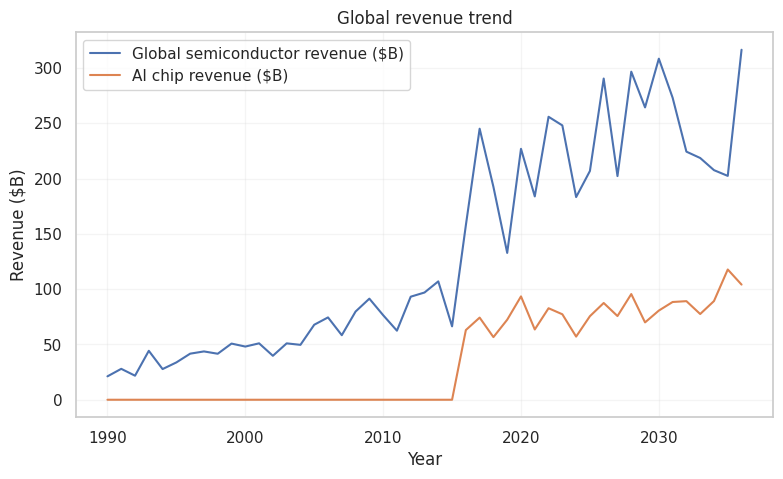

In [69]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(market["Year"], market["Global_Semiconductor_Revenue"] / 1e9, label="Global semiconductor revenue ($B)")
ax.plot(market["Year"], market["AI_Chip_Revenue"] / 1e9, label="AI chip revenue ($B)")
ax.set_title("Global revenue trend")
ax.set_xlabel("Year")
ax.set_ylabel("Revenue ($B)")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

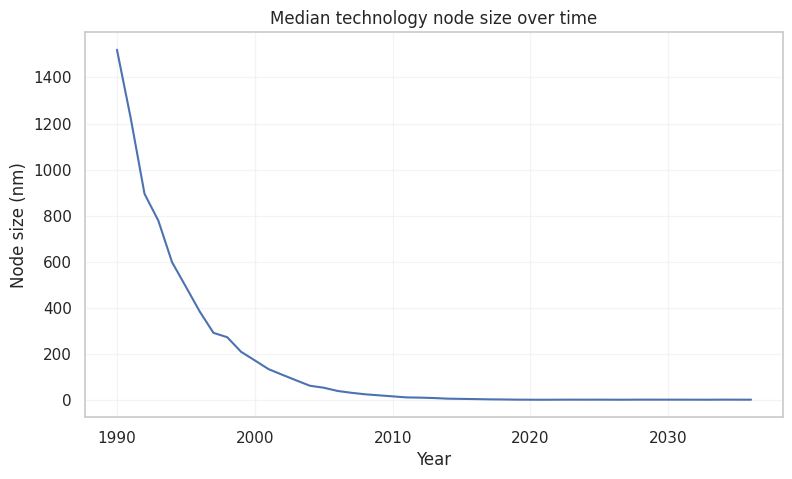

In [70]:
node_trend = tech.groupby("Year", as_index=False)["Node_Size_nm"].median()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(node_trend["Year"], node_trend["Node_Size_nm"])
ax.set_title("Median technology node size over time")
ax.set_xlabel("Year")
ax.set_ylabel("Node size (nm)")
ax.grid(alpha=0.2)
plt.show()

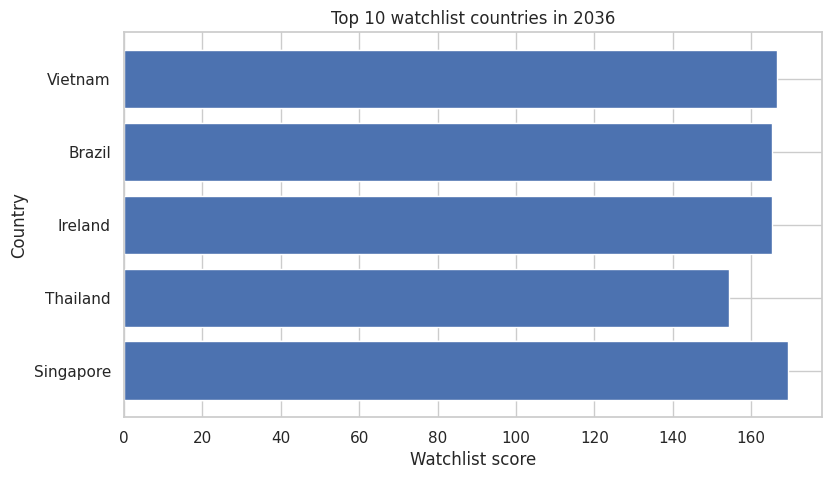

In [71]:
latest_watch = country_year[country_year["Year"] == 2036] \
    .sort_values("Watchlist_Score", ascending=False) \
    .head(10) \
    .sort_values("Watchlist_Score")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(latest_watch["Country"], latest_watch["Watchlist_Score"])
ax.set_title("Top 10 watchlist countries in 2036")
ax.set_xlabel("Watchlist score")
ax.set_ylabel("Country")
plt.show()